In [1]:
import random as r
import matplotlib.pyplot as plt

#Simulation Variables
#PEOPLE = 240
SIZE = 100

class People:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.sick = False
        self.dead = False
        self.immune = False
        self.pZero = None
        self.quarantined = False
        self.tick = 0
    def infected(self, time = 0):
        self.sick = True
        self.tInfected = time
    def recover(self, time):
        self.sick = False
        self.immune = True
        self.tRecovered = time
    def die(self, time):
        self.sick = False
        self.dead = True
        self.tDead = time
    def quarantine(self):
        self.quarantined = True

class Square:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.occupied = False
        self.person = None

def sim1(density):
    """"
    Simulate the spread of an infectitious disease

    Parameters:
        density : float
            Desired population density.

    Returns:
        List of Dictionaries
            Each dictionary holds time keys and the corresponding number of people
            who were infected at that time.


    """
    #set population count based on density percentage
    population = int((SIZE ** 2) * density)

    # populate SIZE x SIZE grid with unoccupied squares
    grid = []
    for i in range(SIZE):
        for j in range(SIZE):
            grid.append(Square(i,j))

    # generate random coords for people, use set to avoid duplicates
    coordinates = set()
    while len(coordinates) < population:
        coordinates.add((r.randint(0,SIZE-1), r.randint(0,SIZE-1)))

    people = [None]*population


    # Assign patient zero
    pZero = r.randint(0,population-1)
    for i, coord in enumerate(coordinates):

        #populate people array for movement later
        people[i] = People(coord[0], coord[1])

        # Patient zero
        if i == pZero:
            people[i].pZero = True
            people[i].infected(0)

        # map people to grid
        index = coord[0] * SIZE + coord[1]
        grid[index].person = people[i]
        grid[index].occupied = True

    #movement, tracker variables
    move = [-1,0,1]
    time = 0
    sickcount = 1
    infectionTimes = {}
    while sickcount < population:
        #increment time
        time += 1
        #iterate through people list People objs
        for person in people:
            while True:
                randx = r.choice(move)
                randy = r.choice(move)
                index = person.x + randx, person.y + randy

                # check x and y are [0,99]
                if 0 <= index[0] < SIZE and 0 <= index[1] < SIZE:
                    #check if the spot we moved to is empty
                    if grid[index[0] * SIZE + index[1]].occupied == False:
                        #empty previous position
                        grid[person.x * SIZE +  person.y].person = None
                        grid[person.x * SIZE +  person.y].occupied = False

                        #move to new position & update person coords
                        grid[index[0] * SIZE + index[1]].person = person
                        grid[index[0] * SIZE + index[1]].occupied = True
                        person.x += randx
                        person.y += randy

                    #Only infect surroundings if person moving is sick
                    for xShift in move:
                        for yShift in move:
                            tIndex = (index[0] + xShift) * SIZE + index[1] + yShift
                            if (xShift != 0 or yShift != 0) and 0 <= index[0] + xShift < SIZE and 0 <= index[1] + yShift < SIZE:
                                if person.sick == True:
                                        #if there is a person,               if person is not already sick         and if that person is not immune     and person is not dead
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == False and grid[tIndex].person.immune == False:
                                        grid[tIndex].person.infected(time)
                                        sickcount += 1
                                else:
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == True and person.immune == False and person.sick == False:
                                        person.infected(time)
                                        sickcount += 1
                else:
                    continue
                break

    for person in people:
        infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1

    return infectionTimes

def sim2(density):
    """"
    Simulate the spread of an infectitious disease with the possibility of people either
    recovering and gaining immunity or dying after 20 time steps.

    Parameters:
        density : float
            Desired population density.

    Returns:
        List of Dictionaries
            Each dictionary holds time keys and the corresponding number of people who either
            died, recovered, or were infected at that time.

    """

    # populate 100x100 grid with unoccupied squares
    population = int((SIZE ** 2) * density)
    grid = []
    for i in range(SIZE):
        for j in range(SIZE):
            grid.append(Square(i,j))

    # generate random coords for people, use set to avoid duplicates
    coordinates = set()
    while len(coordinates) < population:
        coordinates.add((r.randint(0,SIZE-1), r.randint(0,SIZE-1)))

    people = [None]*population


    # Assign patient zero
    pZero = r.randint(0,population-1)
    for i, coord in enumerate(coordinates):

        #populate people array for movement later
        people[i] = People(coord[0], coord[1])

        # Patient zero
        if i == pZero:
            people[i].pZero = True
            people[i].infected()


        # map people to grid
        index = coord[0] * SIZE + coord[1]
        grid[index].person = people[i]
        grid[index].occupied = True

    #movement, tracker variables
    move = [-1,0,1]
    time = 0
    sickcount = 1
    infectionTimes = {}
    recoveryTimes = {}
    deathTimes= {}
    while sickcount > 0:
        #increment time
        time += 1
        #iterate through people list People objs
        for person in people:
            #check dead skip
            if person.dead == True:
                continue
            #increment tick
            if person.sick == True:
                person.tick += 1
                # recover or die
                if person.tick >= 20:
                    chance = r.random()
                    if chance < 0.9:
                        person.recover(time)
                        sickcount -= 1
                    else:
                        grid[person.x * SIZE + person.y].occupied = False
                        grid[person.x * SIZE + person.y].person = None
                        person.die(time)
                        sickcount -= 1
                        continue

            while True:
                randx = r.choice(move)
                randy = r.choice(move)
                index = person.x + randx, person.y + randy

                # check x and y are [0,99]
                if 0 <= index[0] < SIZE and 0 <= index[1] < SIZE:
                    #check if the spot we moved to is empty
                    if grid[index[0] * SIZE + index[1]].occupied == False:
                        #empty previous position
                        grid[person.x * SIZE +  person.y].person = None
                        grid[person.x * SIZE +  person.y].occupied = False

                        #move to new position & update person coords
                        grid[index[0] * SIZE + index[1]].person = person
                        grid[index[0] * SIZE + index[1]].occupied = True
                        person.x += randx
                        person.y += randy

                    #No infect checking for immune people
                    if person.immune == True:
                        break

                    #Check everyone who is not immune
                    for xShift in move:
                        for yShift in move:
                            tIndex = (index[0] + xShift) * SIZE + index[1] + yShift
                            if (xShift != 0 or yShift != 0) and 0 <= index[0] + xShift < SIZE and 0 <= index[1] + yShift < SIZE:
                                if person.sick == True:
                                        #if there is a person,             if person is not already sick         and if that person is not immune
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == False and grid[tIndex].person.immune == False:
                                        grid[tIndex].person.infected(time)
                                        sickcount += 1
                                else:
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == True and person.immune == False and person.sick == False:
                                        person.infected(time)
                                        sickcount += 1
                else:
                    continue
                break

    for person in people:
        if person.immune == True:
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
            recoveryTimes[person.tRecovered] = recoveryTimes.get(person.tRecovered, 0) + 1
        elif person.dead == True:
            deathTimes[person.tDead] = deathTimes.get(person.tDead, 0) + 1
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
        else:
            continue

    return [infectionTimes, recoveryTimes, deathTimes]

def sim3(density):
    """"
    Simulate the spread of an infectitious disease with a quarantine policy in place so that people are removed
    from the grid when they are infected and must either recover or die after 20 time steps.

    Parameters:
        density : float
            Desired population density.

    Returns:
        List of Dictionaries
            Each dictionary holds time keys and the corresponding number of people who either
            died, recovered, or were infected at that time.

    """
    # populate 100x100 grid with unoccupied squares
    population = int((SIZE ** 2) * density)
    grid = []
    for i in range(SIZE):
        for j in range(SIZE):
            grid.append(Square(i,j))

    # generate random coords for people, use set to avoid duplicates
    coordinates = set()
    while len(coordinates) < population:
        coordinates.add((r.randint(0,SIZE-1), r.randint(0,SIZE-1)))

    people = [None] * population


    # Assign patient zero
    pZero = r.randint(0,population-1)
    for i, coord in enumerate(coordinates):

        #populate people array for movement later
        people[i] = People(coord[0], coord[1])

        # Patient zero
        if i == pZero:
            people[i].pZero = True
            people[i].infected()


        # map people to grid
        index = coord[0] * SIZE + coord[1]
        grid[index].person = people[i]
        grid[index].occupied = True

    #movement, tracking variables
    move = [-1,0,1]
    time = 0
    sickcount = 1
    infectionTimes = {}
    recoveryTimes = {}
    deathTimes= {}
    while sickcount > 0:
        #increment time
        time += 1
        #iterate through people list People objs
        for person in people:
            #check dead skip
            if person.dead == True:
                continue
            #increment tick
            if person.sick == True:
                person.tick += 1
                #if not quarantined roll for quarantine chance
                if person.quarantined == False:
                    quarantineChance = r.random()
                    if quarantineChance < 0.5:
                        person.quarantine()
                        grid[person.x * SIZE + person.y].occupied = False
                        grid[person.x * SIZE + person.y].person = None
                # recover or die
                if person.tick >= 20:
                    sickChance = r.random()
                    if sickChance < 0.9:
                        person.recover(time)
                        sickcount -= 1
                        if person.quarantined == True and grid[person.x * SIZE + person.y].occupied == False:
                            grid[person.x * SIZE + person.y].occupied = True
                            grid[person.x * SIZE + person.y].person = person
                            person.quarantined = False
                    else:
                        grid[person.x * SIZE + person.y].occupied = False
                        grid[person.x * SIZE + person.y].person = None
                        person.die(time)
                        sickcount -= 1
                    #skip if either they die or they leave quarantine
                    continue

            #check if
            if person.quarantined == True and grid[person.x * SIZE + person.y].occupied == False and person.sick == False:
                grid[person.x * SIZE + person.y].occupied = True
                grid[person.x * SIZE + person.y].person = person
                person.quarantined = False

            #quarantined can't move
            if person.quarantined == True:
                continue

            while True:
                randx = r.choice(move)
                randy = r.choice(move)
                index = person.x + randx, person.y + randy

                # check x and y are [0,99]
                if 0 <= index[0] < SIZE and 0 <= index[1] < SIZE:
                    #check if the spot we moved to is empty
                    if grid[index[0] * SIZE + index[1]].occupied == False:
                        #empty previous position
                        grid[person.x * SIZE +  person.y].person = None
                        grid[person.x * SIZE +  person.y].occupied = False

                        #move to new position & update person coords
                        grid[index[0] * SIZE + index[1]].person = person
                        grid[index[0] * SIZE + index[1]].occupied = True
                        person.x += randx
                        person.y += randy

                    #No infect checking for immune people
                    if person.immune == True:
                        break

                    #Check everyone who is not immune
                    for xShift in move:
                        for yShift in move:
                            tIndex = (index[0] + xShift) * SIZE + index[1] + yShift
                            if (xShift != 0 or yShift != 0) and 0 <= index[0] + xShift < SIZE and 0 <= index[1] + yShift < SIZE:
                                if person.sick == True:
                                        #if there is a person,             if person is not already sick         and if that person is not immune
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == False and grid[tIndex].person.immune == False:
                                        grid[tIndex].person.infected(time)
                                        sickcount += 1
                                else:
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == True and person.immune == False and person.sick == False:
                                        person.infected(time)
                                        sickcount += 1
                else:
                    continue
                break

    for person in people:
        if person.immune == True:
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
            recoveryTimes[person.tRecovered] = recoveryTimes.get(person.tRecovered, 0) + 1
        elif person.dead == True:
            deathTimes[person.tDead] = deathTimes.get(person.tDead, 0) + 1
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
        else:
            continue
    return [infectionTimes, recoveryTimes, deathTimes]

def sim4(density):
    """"
    Simulate the spread of an infectitious disease with a "mask" policy.

    Parameters:
        density : float
            Desired population density.

    Returns:
        List of Dictionaries
            Each dictionary holds time keys and the corresponding number of people who either
            died, recovered, or were infected at that time.

    """

    # populate 100x100 grid with unoccupied squares
    population = int((SIZE ** 2) * density)
    grid = []
    for i in range(SIZE):
        for j in range(SIZE):
            grid.append(Square(i,j))

    # generate random coords for people, use set to avoid duplicates
    coordinates = set()
    while len(coordinates) < population:
        coordinates.add((r.randint(0,SIZE-1), r.randint(0,SIZE-1)))

    people = [None]*population


    # Assign patient zero
    pZero = r.randint(0,population-1)
    for i, coord in enumerate(coordinates):

        #populate people array for movement later
        people[i] = People(coord[0], coord[1])

        # Patient zero
        if i == pZero:
            people[i].pZero = True
            people[i].infected()


        # map people to grid
        index = coord[0] * SIZE + coord[1]
        grid[index].person = people[i]
        grid[index].occupied = True

    #movement, tracker variables
    move = [-1,0,1]
    time = 0
    sickcount = 1
    infectionTimes = {}
    recoveryTimes = {}
    deathTimes= {}
    while sickcount > 0:
        #increment time
        time += 1
        #iterate through people list People objs
        for person in people:
            #check dead skip
            if person.dead == True:
                continue
            #increment tick
            if person.sick == True:
                person.tick += 1
                # recover or die
                if person.tick >= 20:
                    chance = r.random()
                    if chance < 0.9:
                        person.recover(time)
                        sickcount -= 1
                    else:
                        grid[person.x * SIZE + person.y].occupied = False
                        grid[person.x * SIZE + person.y].person = None
                        person.die(time)
                        sickcount -= 1
                        continue

            while True:
                randx = r.choice(move)
                randy = r.choice(move)
                index = person.x + randx, person.y + randy

                # check x and y are [0,99]
                if 0 <= index[0] < SIZE and 0 <= index[1] < SIZE:
                    #check if the spot we're moving to is empty
                    if grid[index[0] * SIZE + index[1]].occupied == False:
                        #empty previous position
                        grid[person.x * SIZE +  person.y].person = None
                        grid[person.x * SIZE +  person.y].occupied = False

                        #move to new position & update person coords
                        grid[index[0] * SIZE + index[1]].person = person
                        grid[index[0] * SIZE + index[1]].occupied = True
                        person.x += randx
                        person.y += randy

                    #No infect checking for immune people
                    if person.immune == True:
                        break

                    #Check everyone who is not immune
                    for xShift in move:
                        for yShift in move:
                            tIndex = (index[0] + xShift) * SIZE + index[1] + yShift
                            if (xShift != 0 or yShift != 0) and 0 <= index[0] + xShift < SIZE and 0 <= index[1] + yShift < SIZE:
                                if person.sick == True:
                                        #if there is a person,             if person is not already sick         and if that person is not immune
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == False and grid[tIndex].person.immune == False:
                                        if r.random() < 0.51:
                                            grid[tIndex].person.infected(time)
                                            sickcount += 1
                                else:
                                    if grid[tIndex].occupied == True and grid[tIndex].person.sick == True and person.immune == False and person.sick == False:
                                        if r.random() < 0.51:
                                            person.infected(time)
                                            sickcount += 1
                else:
                    continue
                break

    for person in people:
        if person.immune == True:
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
            recoveryTimes[person.tRecovered] = recoveryTimes.get(person.tRecovered, 0) + 1
        elif person.dead == True:
            deathTimes[person.tDead] = deathTimes.get(person.tDead, 0) + 1
            infectionTimes[person.tInfected] = infectionTimes.get(person.tInfected, 0) + 1
        else:
            continue

    return [infectionTimes, recoveryTimes, deathTimes]




In [2]:

def runsim(runs, simVersion, density):
    """
    Run simulations

    Parameters:
        runs : int
            Number of runs
        simVersion : int
            What version of the simulation to run
    Returns:
        list of lists of dictionaries holding time, event data pairs
    """
    results = []
    if simVersion == 1:
        for _ in range(runs):
            result = sim1(density)
            results.append(result)
        return results
    elif simVersion == 2:
        for _ in range(runs):
            result = sim2(density)
            results.append(result)
        return results
    elif simVersion == 3:
        for _ in range(runs):
            result = sim3(density)
            results.append(result)
        return results
    elif simVersion == 4:
        for _ in range(runs):
            result = sim4(density)
            results.append(result)
        return results

def calculateAverages(simResults, simVersion):
    """
    Calculate average infections, recoveries, and deaths

    Parameters:
        simResults : list[dict]
            A list of dictionaries that is dependent on the simVersion that returned it;
            Sim1:
                [infectionTimes{time : infections at time step} * # of runs]
            Sim2:
                [[infectionTimes{time : infections at time step}, recoveryTimes{time : recoveries at time step}, deathTimes{time : deaths at time step}] * # of runs]
        simVersion : int
            What version is running

    Return:
        list of dictionaries with time keys and average event per/at time
    """
    infectionsPerTime = {}
    infectionsAtTime = {}
    if simVersion == 2:
        recoveriesPerTime = {}
        recoveriesAtTime = {}
        deathsPerTime = {}
        deathsAtTime = {}

    for result in simResults:
        totalinfections = 0
        totalRecoveries = 0
        totalDeaths = 0
        if simVersion == 1:
            for key in sorted(result):
                totalinfections += result[key]
                if key not in infectionsPerTime:
                    infectionsPerTime[key] = [0] * 2
                if key not in infectionsAtTime:
                    infectionsAtTime[key] = [0] * 2

                infectionsPerTime[key][0] += result[key]
                infectionsPerTime[key][1] += 1
                infectionsAtTime[key][0] += totalinfections
                infectionsAtTime[key][1] += 1

        elif simVersion == 2:
            for key in sorted(result[0]):
                totalinfections += result[0][key]

                if key not in infectionsPerTime:
                    infectionsPerTime[key] = [0] * 2
                if key not in infectionsAtTime:
                    infectionsAtTime[key] = [0] * 2
                infectionsPerTime[key][0] += result[0][key]
                infectionsPerTime[key][1] += 1
                infectionsAtTime[key][0] += totalinfections
                infectionsAtTime[key][1] += 1

            for key in sorted(result[1]):
                totalRecoveries += result[1][key]
                if key not in recoveriesPerTime:
                    recoveriesPerTime[key] = [0] * 2
                if key not in recoveriesAtTime:
                    recoveriesAtTime[key] = [0] * 2

                recoveriesPerTime[key][0] += result[1][key]
                recoveriesPerTime[key][1] += 1
                recoveriesAtTime[key][0] += totalRecoveries
                recoveriesAtTime[key][1] += 1

            for key in sorted(result[2]):
                totalDeaths += result[2][key]
                if key not in deathsPerTime:
                    deathsPerTime[key] = [0] * 2
                if key not in deathsAtTime:
                    deathsAtTime[key] = [0] * 2

                deathsPerTime[key][0] += result[2][key]
                deathsPerTime[key][1] += 1
                deathsAtTime[key][0] += totalDeaths
                deathsAtTime[key][1] += 1

    keysI = sorted(infectionsPerTime.keys())
    avgInfectionsPerTime = {}
    avgInfectionsAtTime = {}
    if simVersion == 2:
        avgRecoveriesPerTime = {}
        avgRecoveriesAtTime = {}
        avgDeathsPerTime = {}
        avgDeathsAtTime = {}
        keysR = sorted(recoveriesPerTime.keys())
        keysD = sorted(deathsPerTime.keys())

    for key in keysI:
        avgInfectionsPerTime[key] = infectionsPerTime[key][0] / infectionsPerTime[key][1]
        avgInfectionsAtTime[key] = infectionsAtTime[key][0] / infectionsAtTime[key][1]

    if simVersion == 2:
        for key in keysR:
            avgRecoveriesPerTime[key] = recoveriesPerTime[key][0] / recoveriesPerTime[key][1]
            avgRecoveriesAtTime[key] = recoveriesAtTime[key][0] / recoveriesAtTime[key][1]
        for key in keysD:
            avgDeathsPerTime[key] = deathsPerTime[key][0] / deathsPerTime[key][1]
            avgDeathsAtTime[key] = deathsAtTime[key][0] / deathsAtTime[key][1]

    if simVersion == 2:
        return avgInfectionsPerTime, avgInfectionsAtTime, avgRecoveriesPerTime, avgRecoveriesAtTime, avgDeathsPerTime, avgDeathsAtTime

    return avgInfectionsPerTime,avgInfectionsAtTime



In [3]:
def graphV1(averages, density):
    fig = plt.figure(figsize=(10,8), dpi=80)
    gs = fig.add_gridspec(2, 1, wspace= .3)
    fig.suptitle(f"No Recovery @ {density * 100}% Population Density")
    (ax1), (ax2) = gs.subplots(sharex = "col")

    ax1.plot(averages[0].keys(), averages[0].values())
    ax1.set_title("Infections Per Time")
    plt.subplots_adjust(hspace=.3)
    ax2.plot(averages[1].keys(), averages[1].values())
    ax2.set_title("Infections At Time")


    plt.show()

def graphV2(averages, density):
    fig = plt.figure(figsize=(20,10), dpi=80)
    gs = fig.add_gridspec(2, 3, wspace= .3)
    fig.suptitle(f"Simulating with death and recovery @ {density * 100}% Population Density")

    (ax1, ax2, ax3), (ax4, ax5, ax6) = gs.subplots(sharex = "col")

    ax1.plot(averages[0].keys(), averages[0].values())
    ax1.set_title("Infections Per Time")
    ax1.set_ylabel("Infections", fontsize = 13)
    ax4.plot(averages[1].keys(), averages[1].values())
    ax4.set_title("Infections At Time")
    ax4.set_ylabel("Infections", fontsize = 13)
    ax4.set_xlabel("Time", fontsize = 13)

    ax2.plot(averages[2].keys(), averages[2].values())
    ax2.set_title("Recoveries Per Time")
    ax2.set_ylabel("Recoveries", fontsize = 13)
    ax5.plot(averages[3].keys(), averages[3].values())
    ax5.set_title("Recoveries At Time")
    ax5.set_ylabel("Recoveries", fontsize = 13)
    ax5.set_xlabel("Time", fontsize = 13)

    ax3.plot(averages[4].keys(), averages[4].values())
    ax3.set_title("Deaths Per Time")
    ax3.set_ylabel("Deaths", fontsize = 13)
    ax6.plot(averages[5].keys(), averages[5].values())
    ax6.set_title("Deaths At Time")
    ax6.set_ylabel("Deaths", fontsize = 13)
    ax6.set_xlabel("Time", fontsize = 13)

    plt.show()

def graphV3(averages, density, policy):
    fig = plt.figure(figsize=(20,10), dpi=80)
    gs = fig.add_gridspec(2, 3, wspace= .3)
    fig.suptitle(f"Simulating with {policy} Policy @ {density * 100}% Population Density")

    (ax1, ax2, ax3), (ax4, ax5, ax6) = gs.subplots(sharex = "col")

    ax1.plot(averages[0].keys(), averages[0].values())
    ax1.set_title("Infections Per Time")
    ax1.set_ylabel("Infections", fontsize = 13)
    ax4.plot(averages[1].keys(), averages[1].values())
    ax4.set_title("Infections At Time")
    ax4.set_ylabel("Infections", fontsize = 13)
    ax4.set_xlabel("Time", fontsize = 13)

    ax2.plot(averages[2].keys(), averages[2].values())
    ax2.set_title("Recoveries Per Time")
    ax2.set_ylabel("Recoveries", fontsize = 13)
    ax5.plot(averages[3].keys(), averages[3].values())
    ax5.set_title("Recoveries At Time")
    ax5.set_ylabel("Recoveries", fontsize = 13)
    ax5.set_xlabel("Time", fontsize = 13)

    ax3.plot(averages[4].keys(), averages[4].values())
    ax3.set_title("Deaths Per Time")
    ax3.set_ylabel("Deaths", fontsize = 13)
    ax6.plot(averages[5].keys(), averages[5].values())
    ax6.set_title("Deaths At Time")
    ax6.set_ylabel("Deaths", fontsize = 13)
    ax6.set_xlabel("Time", fontsize = 13)

    plt.show()

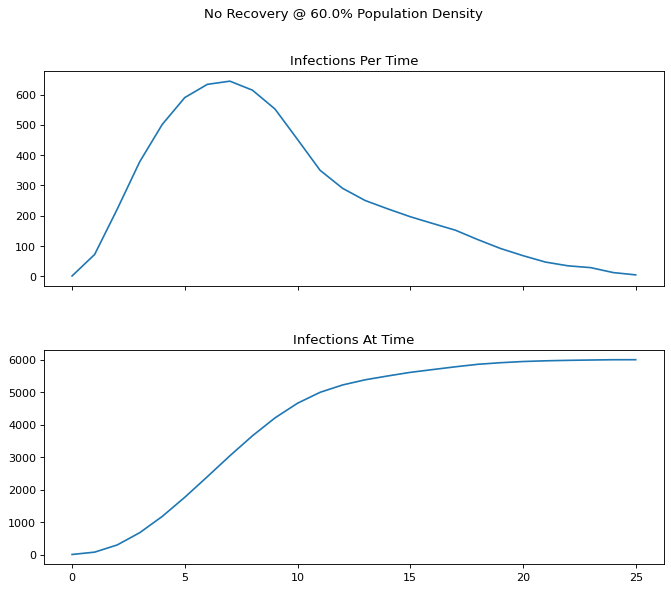

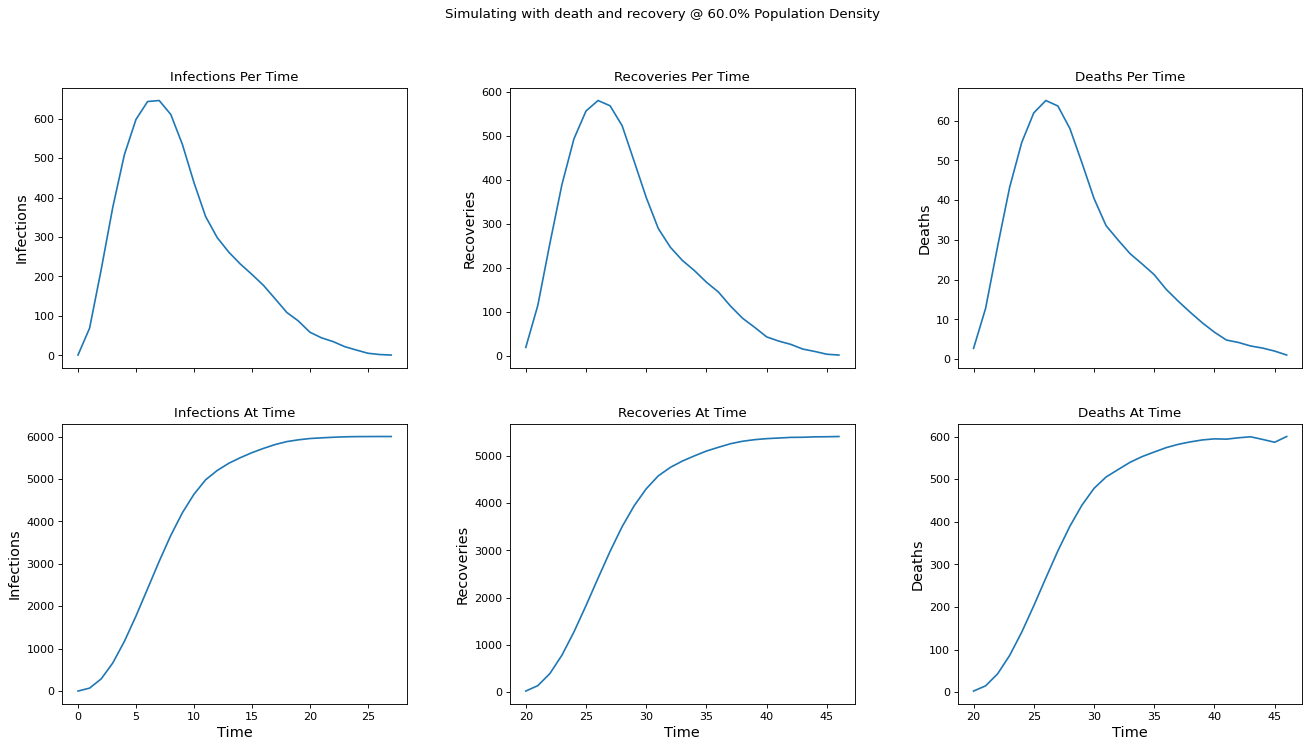

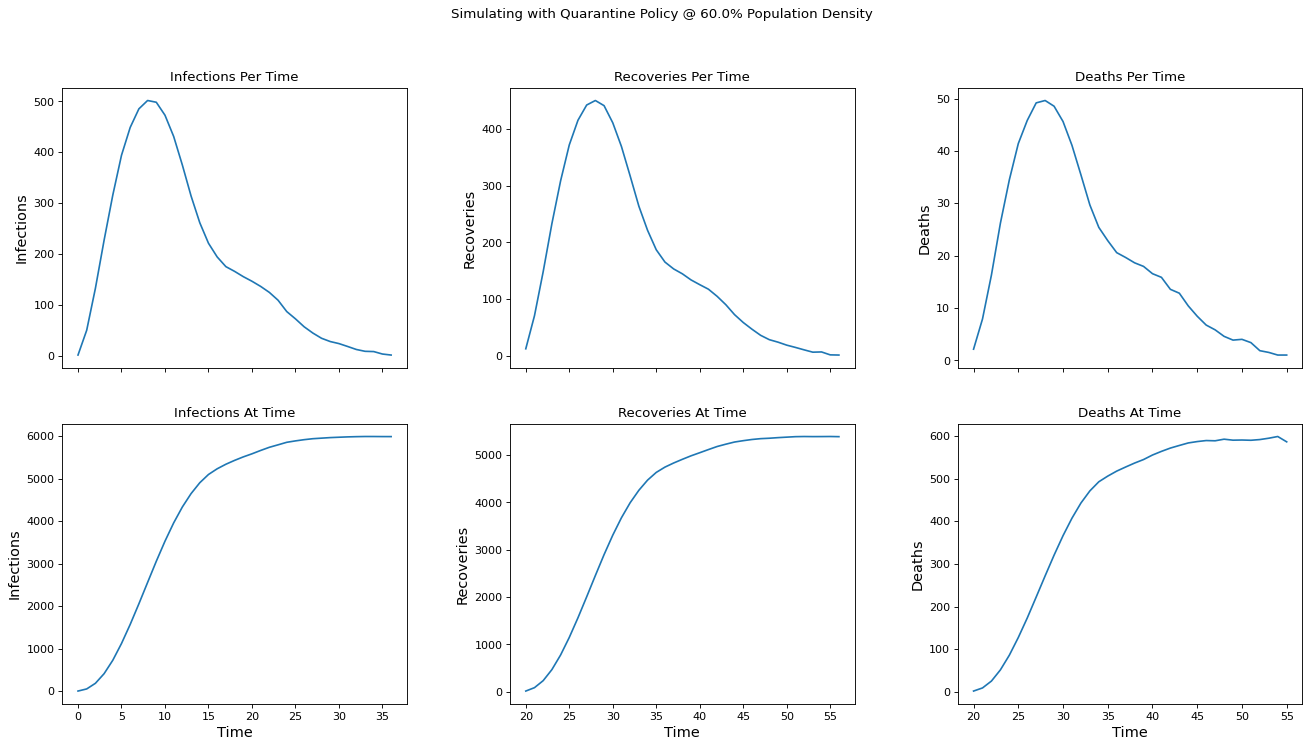

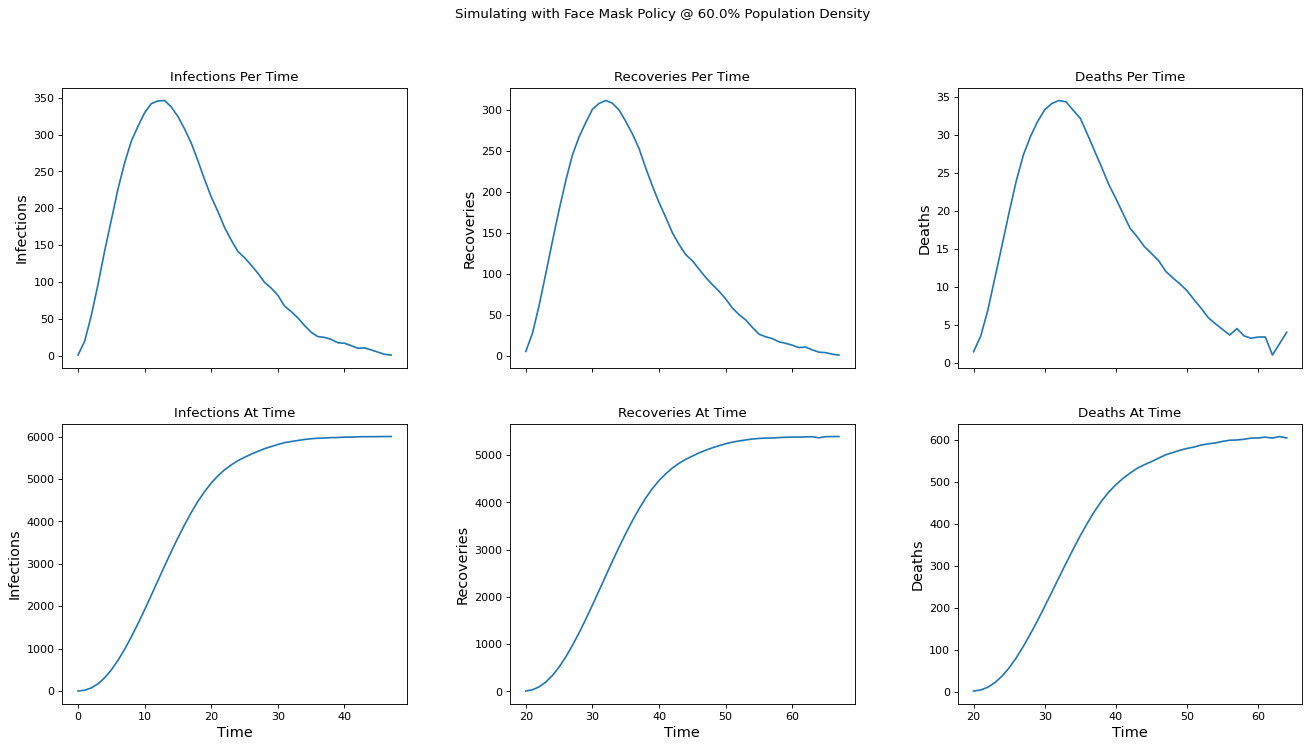

In [4]:
#Normal 60% Population Density

v1Results60 = runsim(1000, 1, 0.6)

v2Results60 = runsim(1000, 2, 0.6)

v3Results60 = runsim(1000, 3, 0.6)

v4Results60 = runsim(1000, 4, 0.6)

v1Averages60 = calculateAverages(v1Results60, 1)
graphV1(v1Averages60, 0.6)

v2Averages60 = calculateAverages(v2Results60, 2)
graphV2(v2Averages60, 0.6)

v3Averages60 = calculateAverages(v3Results60, 2)
graphV3(v3Averages60, 0.6, "Quarantine")

v4Averages60 = calculateAverages(v4Results60, 2)
graphV3(v4Averages60, 0.6, "Face Mask")


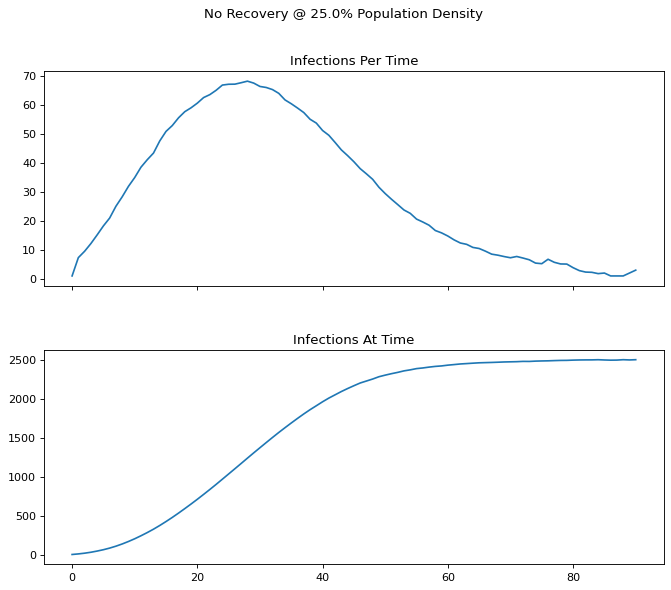

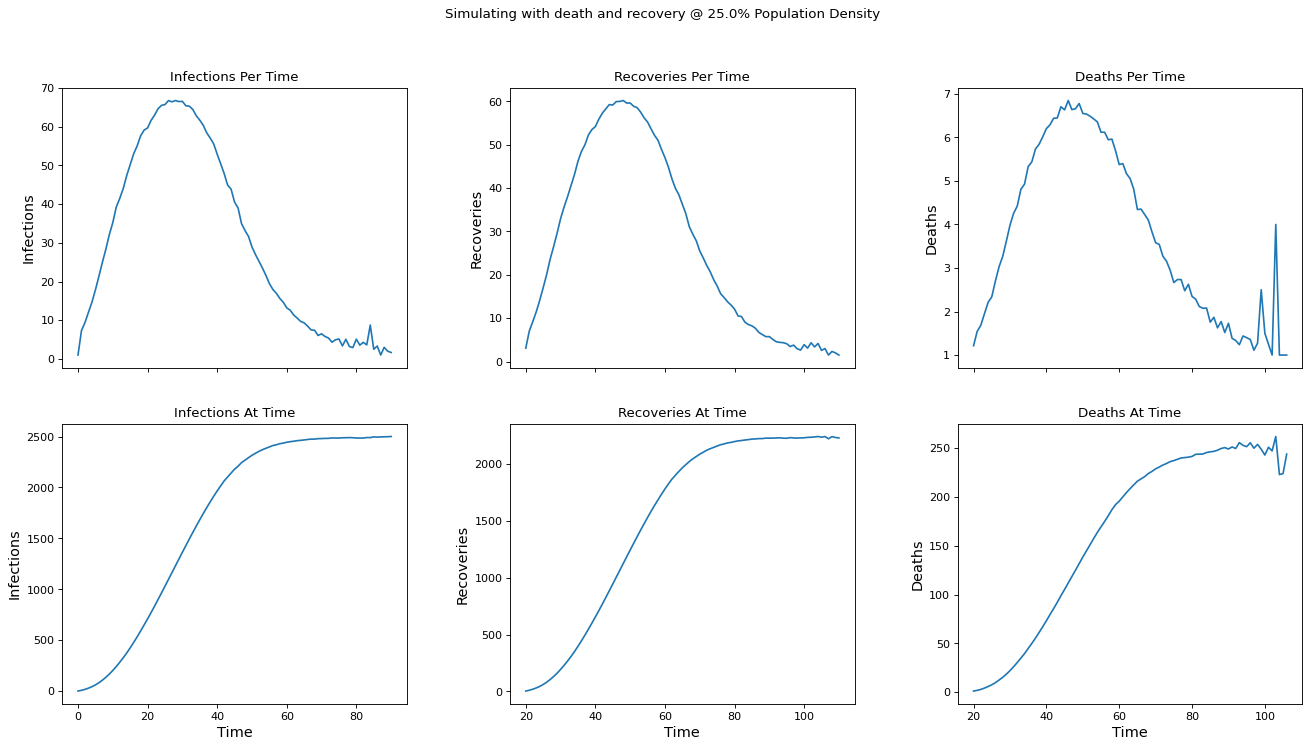

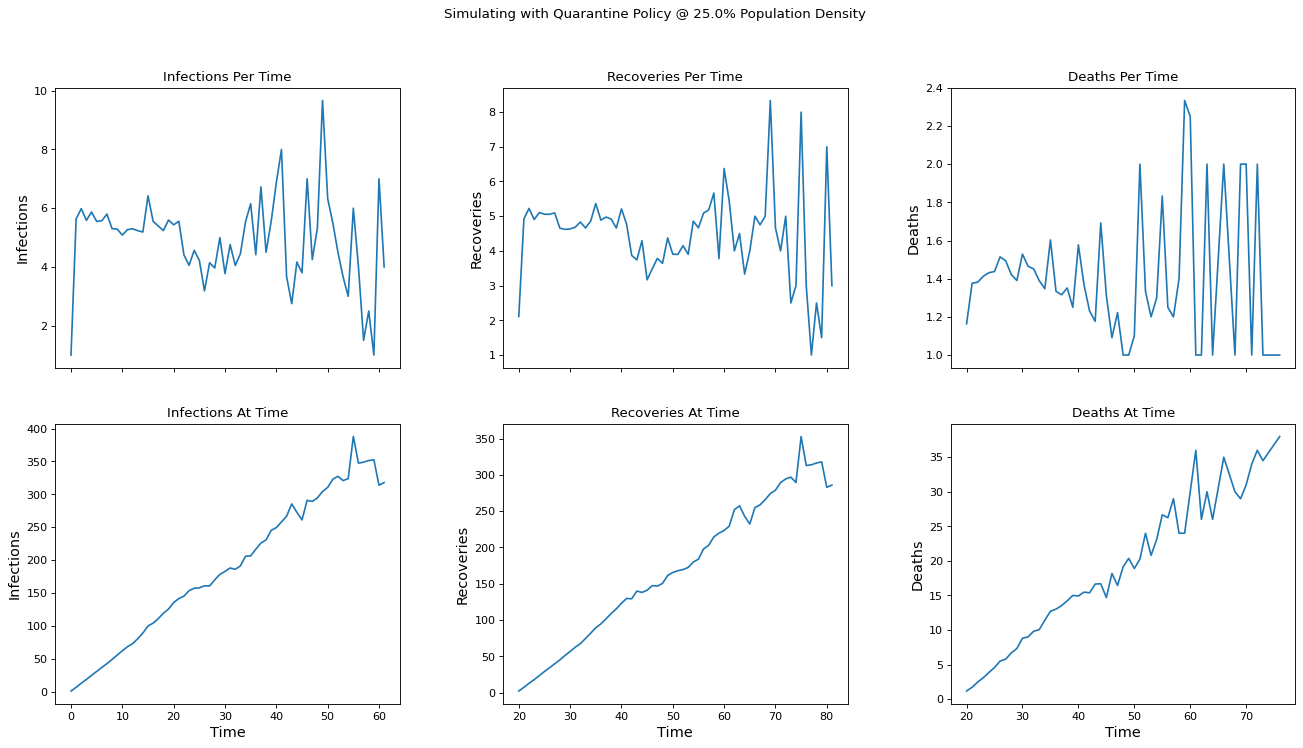

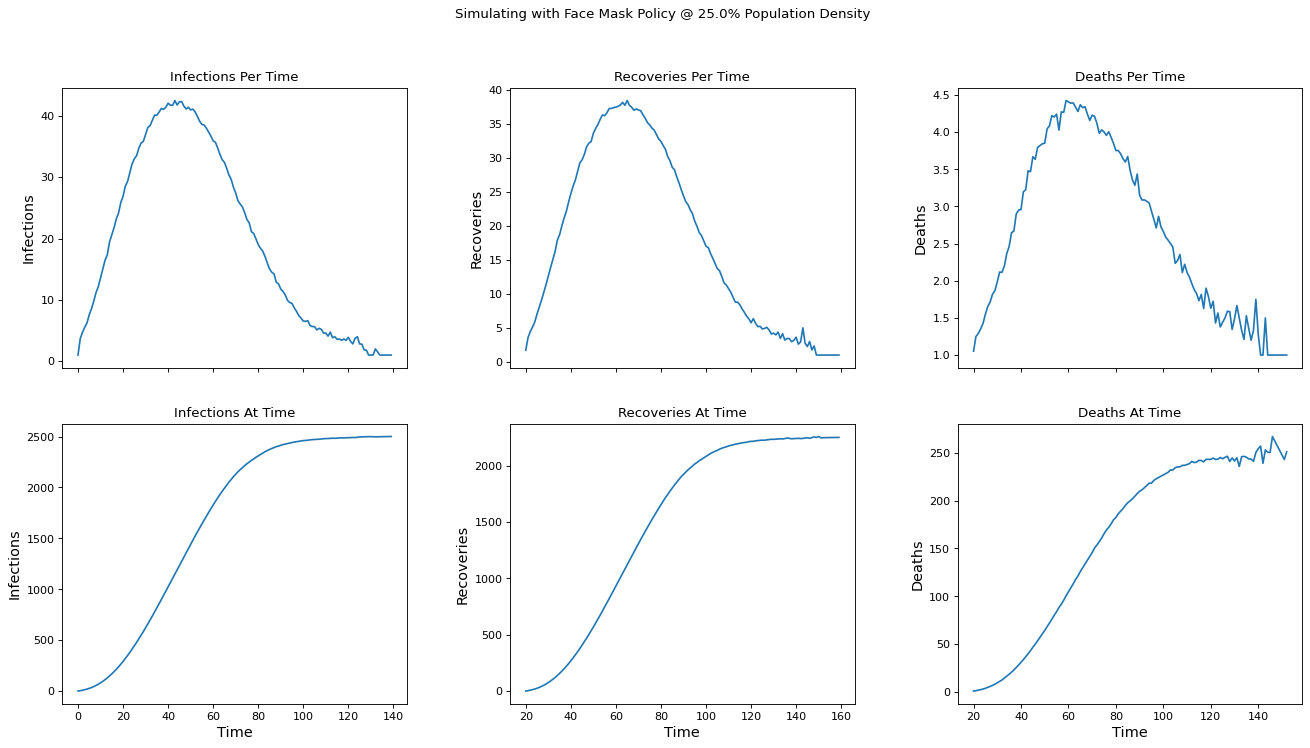

In [5]:
# 25% Population Density

v1Results25 = runsim(1000, 1, 0.25)

v2Results25 = runsim(1000, 2, 0.25)

v3Results25 = runsim(1000, 3, 0.25)

v4Results25 = runsim(1000, 4, 0.25)

v1Averages25 = calculateAverages(v1Results25, 1)
graphV1(v1Averages25, 0.25)

v2Averages25 = calculateAverages(v2Results25, 2)
graphV2(v2Averages25, 0.25)

v3Averages25 = calculateAverages(v3Results25, 2)
graphV3(v3Averages25, 0.25, "Quarantine")

v4Averages25 = calculateAverages(v4Results25, 2)
graphV3(v4Averages25, 0.25, "Face Mask")

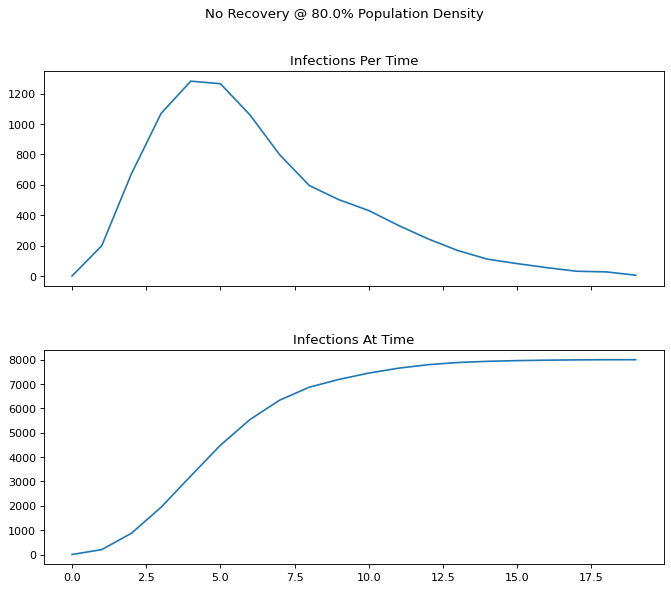

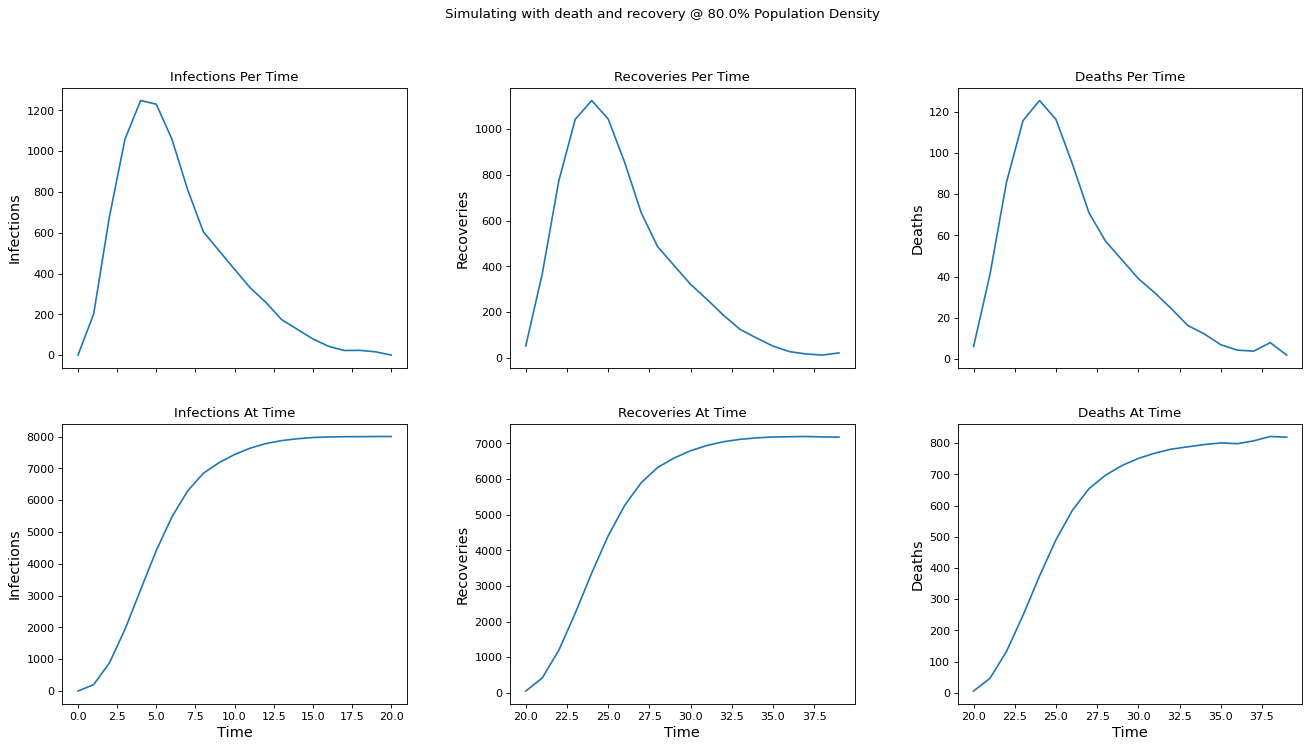

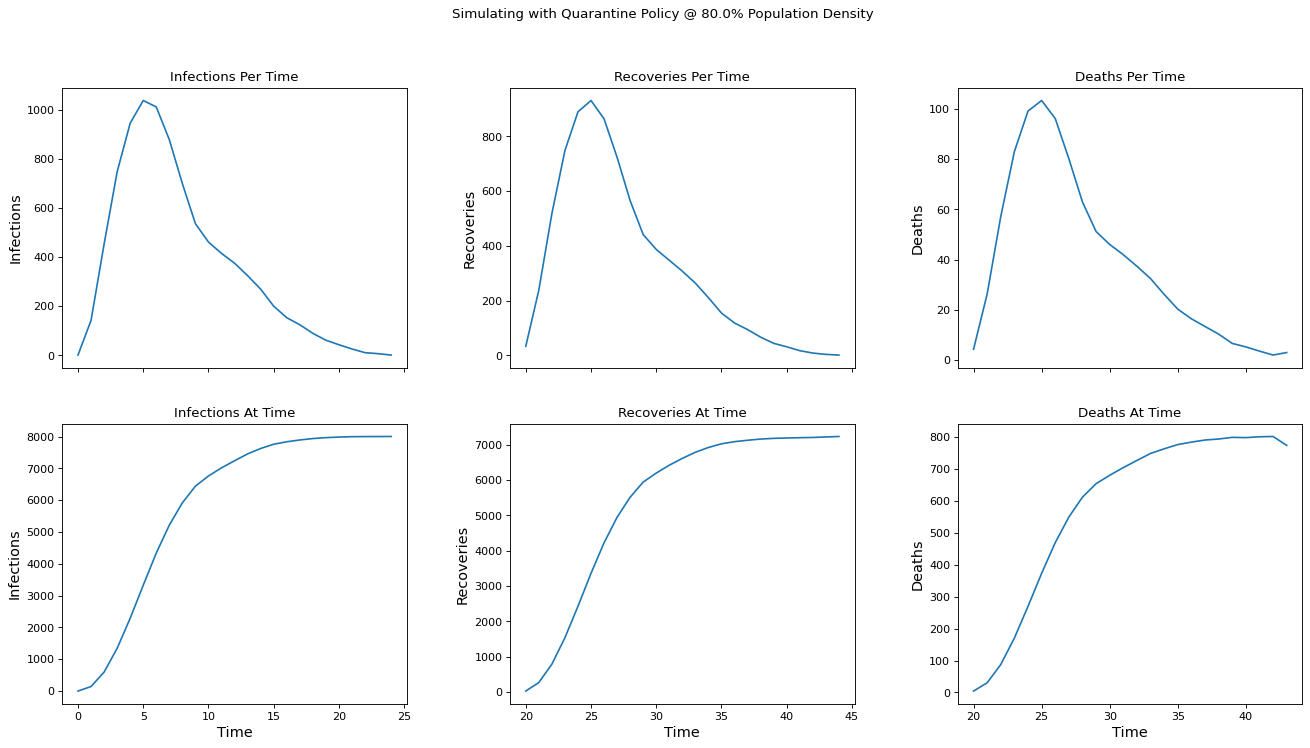

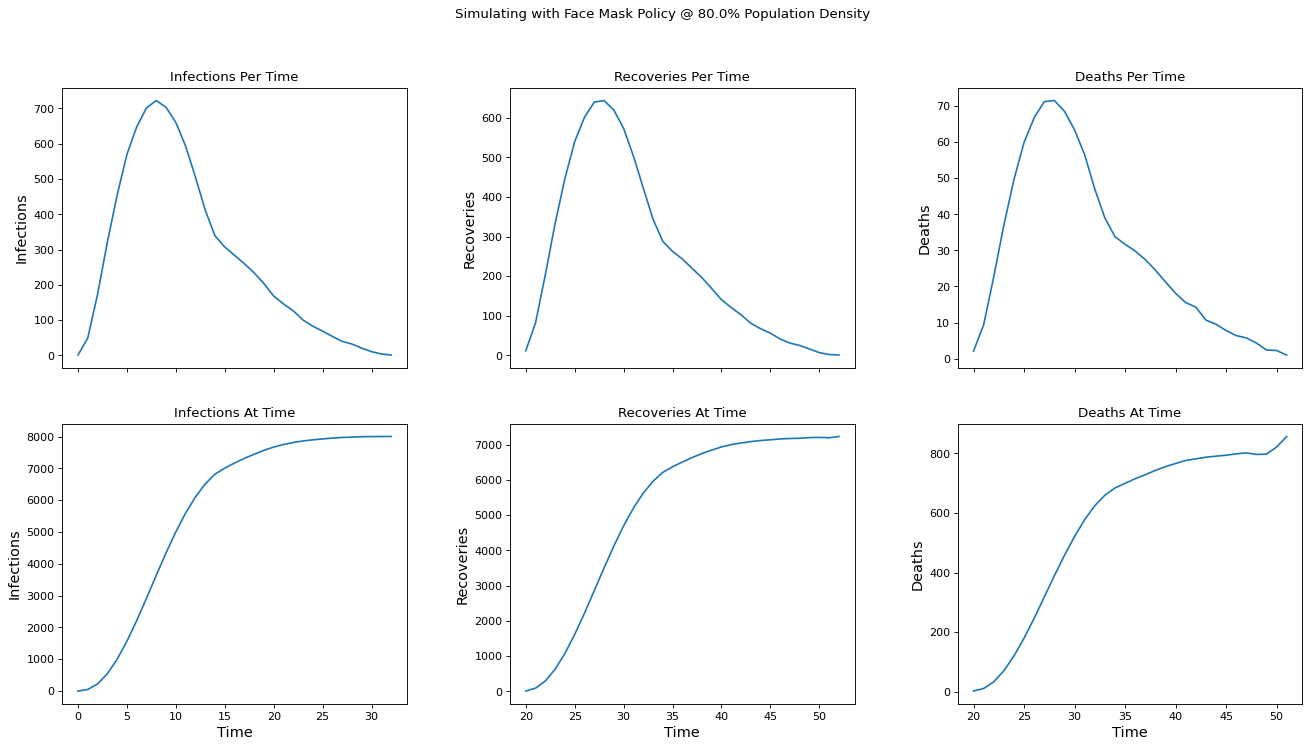

In [6]:
# 80% Population Density

v1Results80 = runsim(1000, 1, 0.8)

v2Results80 = runsim(1000, 2, 0.8)

v3Results80 = runsim(1000, 3, 0.8)

v4Results80 = runsim(1000, 4, 0.8)

v1Averages80 = calculateAverages(v1Results80, 1)
graphV1(v1Averages80, 0.8)

v2Averages80 = calculateAverages(v2Results80, 2)
graphV2(v2Averages80, 0.8)

v3Averages80 = calculateAverages(v3Results80, 2)
graphV3(v3Averages80, 0.8, "Quarantine")

v4Averages80 = calculateAverages(v4Results80, 2)
graphV3(v4Averages80, 0.8, "Face Mask")
